In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically

import skimage as ski
# from skimage.measure import label
from scipy.spatial import KDTree


In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID = 'S222-2_a'

In [3]:
image      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/image.png',       cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/mask.png',        cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/weka.png',        cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/label.png',       cv2.IMREAD_GRAYSCALE)


In [4]:

roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image = cv2.subtract(image, background)

roi_image = cv2.bitwise_and(image, image, mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# apply opening to roi_annotation to remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel, iterations=3)
roi_annotation[roi_annotation > 0] = 255


gt_builder = TopologyBuilder()
roi_label = cv2.bitwise_and(label, label, mask=roi_mask)
roi_label = cv2.morphologyEx(roi_label, cv2.MORPH_CLOSE, kernel, iterations=3)
gt_graph = gt_builder.build_seed_graph(roi_label)


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [5]:

annotation_component = np.asarray(ski.measure.label(roi_annotation, connectivity=2))

# 2. 骨架化 + 種子切分
topology_builder = TopologyBuilder(segment_length=3.0)
global_graph = topology_builder.build_seed_graph(roi_annotation, roi_image)

# 從 labeled image 補上 component_id
for node in global_graph.nodes():
    y, x = node
    global_graph.nodes[node]["component_id"] = int(annotation_component[int(y), int(x)])

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


## DBSCAN Clustering on Global Graph Nodes

In [9]:
from sklearn.cluster import DBSCAN

# Extract node positions (y, x) as feature matrix
nodes = list(global_graph.nodes())
node_positions = np.array([[y, x] for y, x in nodes])  # shape: (N, 2)

# DBSCAN clustering — tune eps and min_samples as needed
eps = 20          # max distance between two points to be in the same neighborhood
min_samples = 10   # min points to form a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = dbscan.fit_predict(node_positions)  # -1 = noise

# Assign cluster labels back to graph nodes
for node, cluster_id in zip(nodes, cluster_labels):
    global_graph.nodes[node]["cluster_id"] = int(cluster_id)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = np.sum(cluster_labels == -1)
print(f"Nodes: {len(nodes)}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise}")

Nodes: 1402
Clusters found: 49
Noise points:   263


## Evaluate Clusters Using GT Label Image

In [10]:
from collections import Counter
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

# Build GT fiber label (connected components from label image)
gt_fiber_label = ski.measure.label(roi_label > 0, connectivity=2)  # shape: (H, W), int

# For each node, look up its GT fiber id (0 = background / not on a fiber)
node_gt_fiber_ids  = np.array([gt_fiber_label[int(y), int(x)] for y, x in nodes])
node_cluster_ids   = cluster_labels.copy()

# --- Per-cluster statistics ---
cluster_stats = {}
for cid in sorted(set(node_cluster_ids)):
    mask_c   = node_cluster_ids == cid
    gt_ids   = node_gt_fiber_ids[mask_c]
    counter  = Counter(gt_ids)
    majority_gt, majority_count = counter.most_common(1)[0]
    purity   = majority_count / mask_c.sum()
    cluster_stats[cid] = {
        "size":        int(mask_c.sum()),
        "majority_gt": int(majority_gt),
        "purity":      float(purity),
        "gt_coverage": counter,
    }

# Overall purity (weighted by cluster size, excluding noise cluster -1)
valid_mask    = node_cluster_ids != -1
pure_counts   = sum(
    s["purity"] * s["size"]
    for cid, s in cluster_stats.items() if cid != -1
)
total_valid   = valid_mask.sum()
overall_purity = pure_counts / total_valid if total_valid > 0 else 0.0

# sklearn metrics (ignore noise nodes for cleaner signal)
hom = homogeneity_score(node_gt_fiber_ids[valid_mask], node_cluster_ids[valid_mask])
com = completeness_score(node_gt_fiber_ids[valid_mask], node_cluster_ids[valid_mask])
vme = v_measure_score  (node_gt_fiber_ids[valid_mask], node_cluster_ids[valid_mask])

print(f"Overall cluster purity : {overall_purity:.3f}")
print(f"Homogeneity            : {hom:.3f}")
print(f"Completeness           : {com:.3f}")
print(f"V-measure              : {vme:.3f}")
print()
print(f"{'Cluster':>8}  {'Size':>6}  {'Purity':>7}  Majority GT fiber")
print("-" * 45)
for cid, s in sorted(cluster_stats.items(), key=lambda x: x[1]["size"], reverse=True)[:20]:
    label_tag = "(noise)" if cid == -1 else ""
    print(f"{cid:>8}  {s['size']:>6}  {s['purity']:>7.3f}  GT={s['majority_gt']}  {label_tag}")

Overall cluster purity : 0.845
Homogeneity            : 0.888
Completeness           : 0.807
V-measure              : 0.846

 Cluster    Size   Purity  Majority GT fiber
---------------------------------------------
      -1     263    0.141  GT=0  (noise)
      40      83    0.831  GT=62  
      16      57    0.965  GT=26  
       5      51    0.843  GT=5  
      37      46    0.783  GT=53  
      38      45    0.578  GT=56  
      24      40    0.925  GT=30  
       4      38    0.895  GT=3  
      17      38    0.947  GT=23  
      41      38    0.711  GT=63  
      10      36    0.861  GT=13  
      39      35    0.800  GT=58  
      26      33    0.848  GT=30  
       3      26    0.692  GT=3  
       6      25    0.840  GT=6  
      21      25    0.960  GT=26  
      18      22    1.000  GT=27  
       8      21    0.714  GT=11  
       1      20    0.950  GT=3  
       2      20    0.950  GT=4  


## Visualization

/tmp/ipykernel_1948938/2579329521.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap           = plt.cm.get_cmap("tab20", max(len(unique_cids), 1))


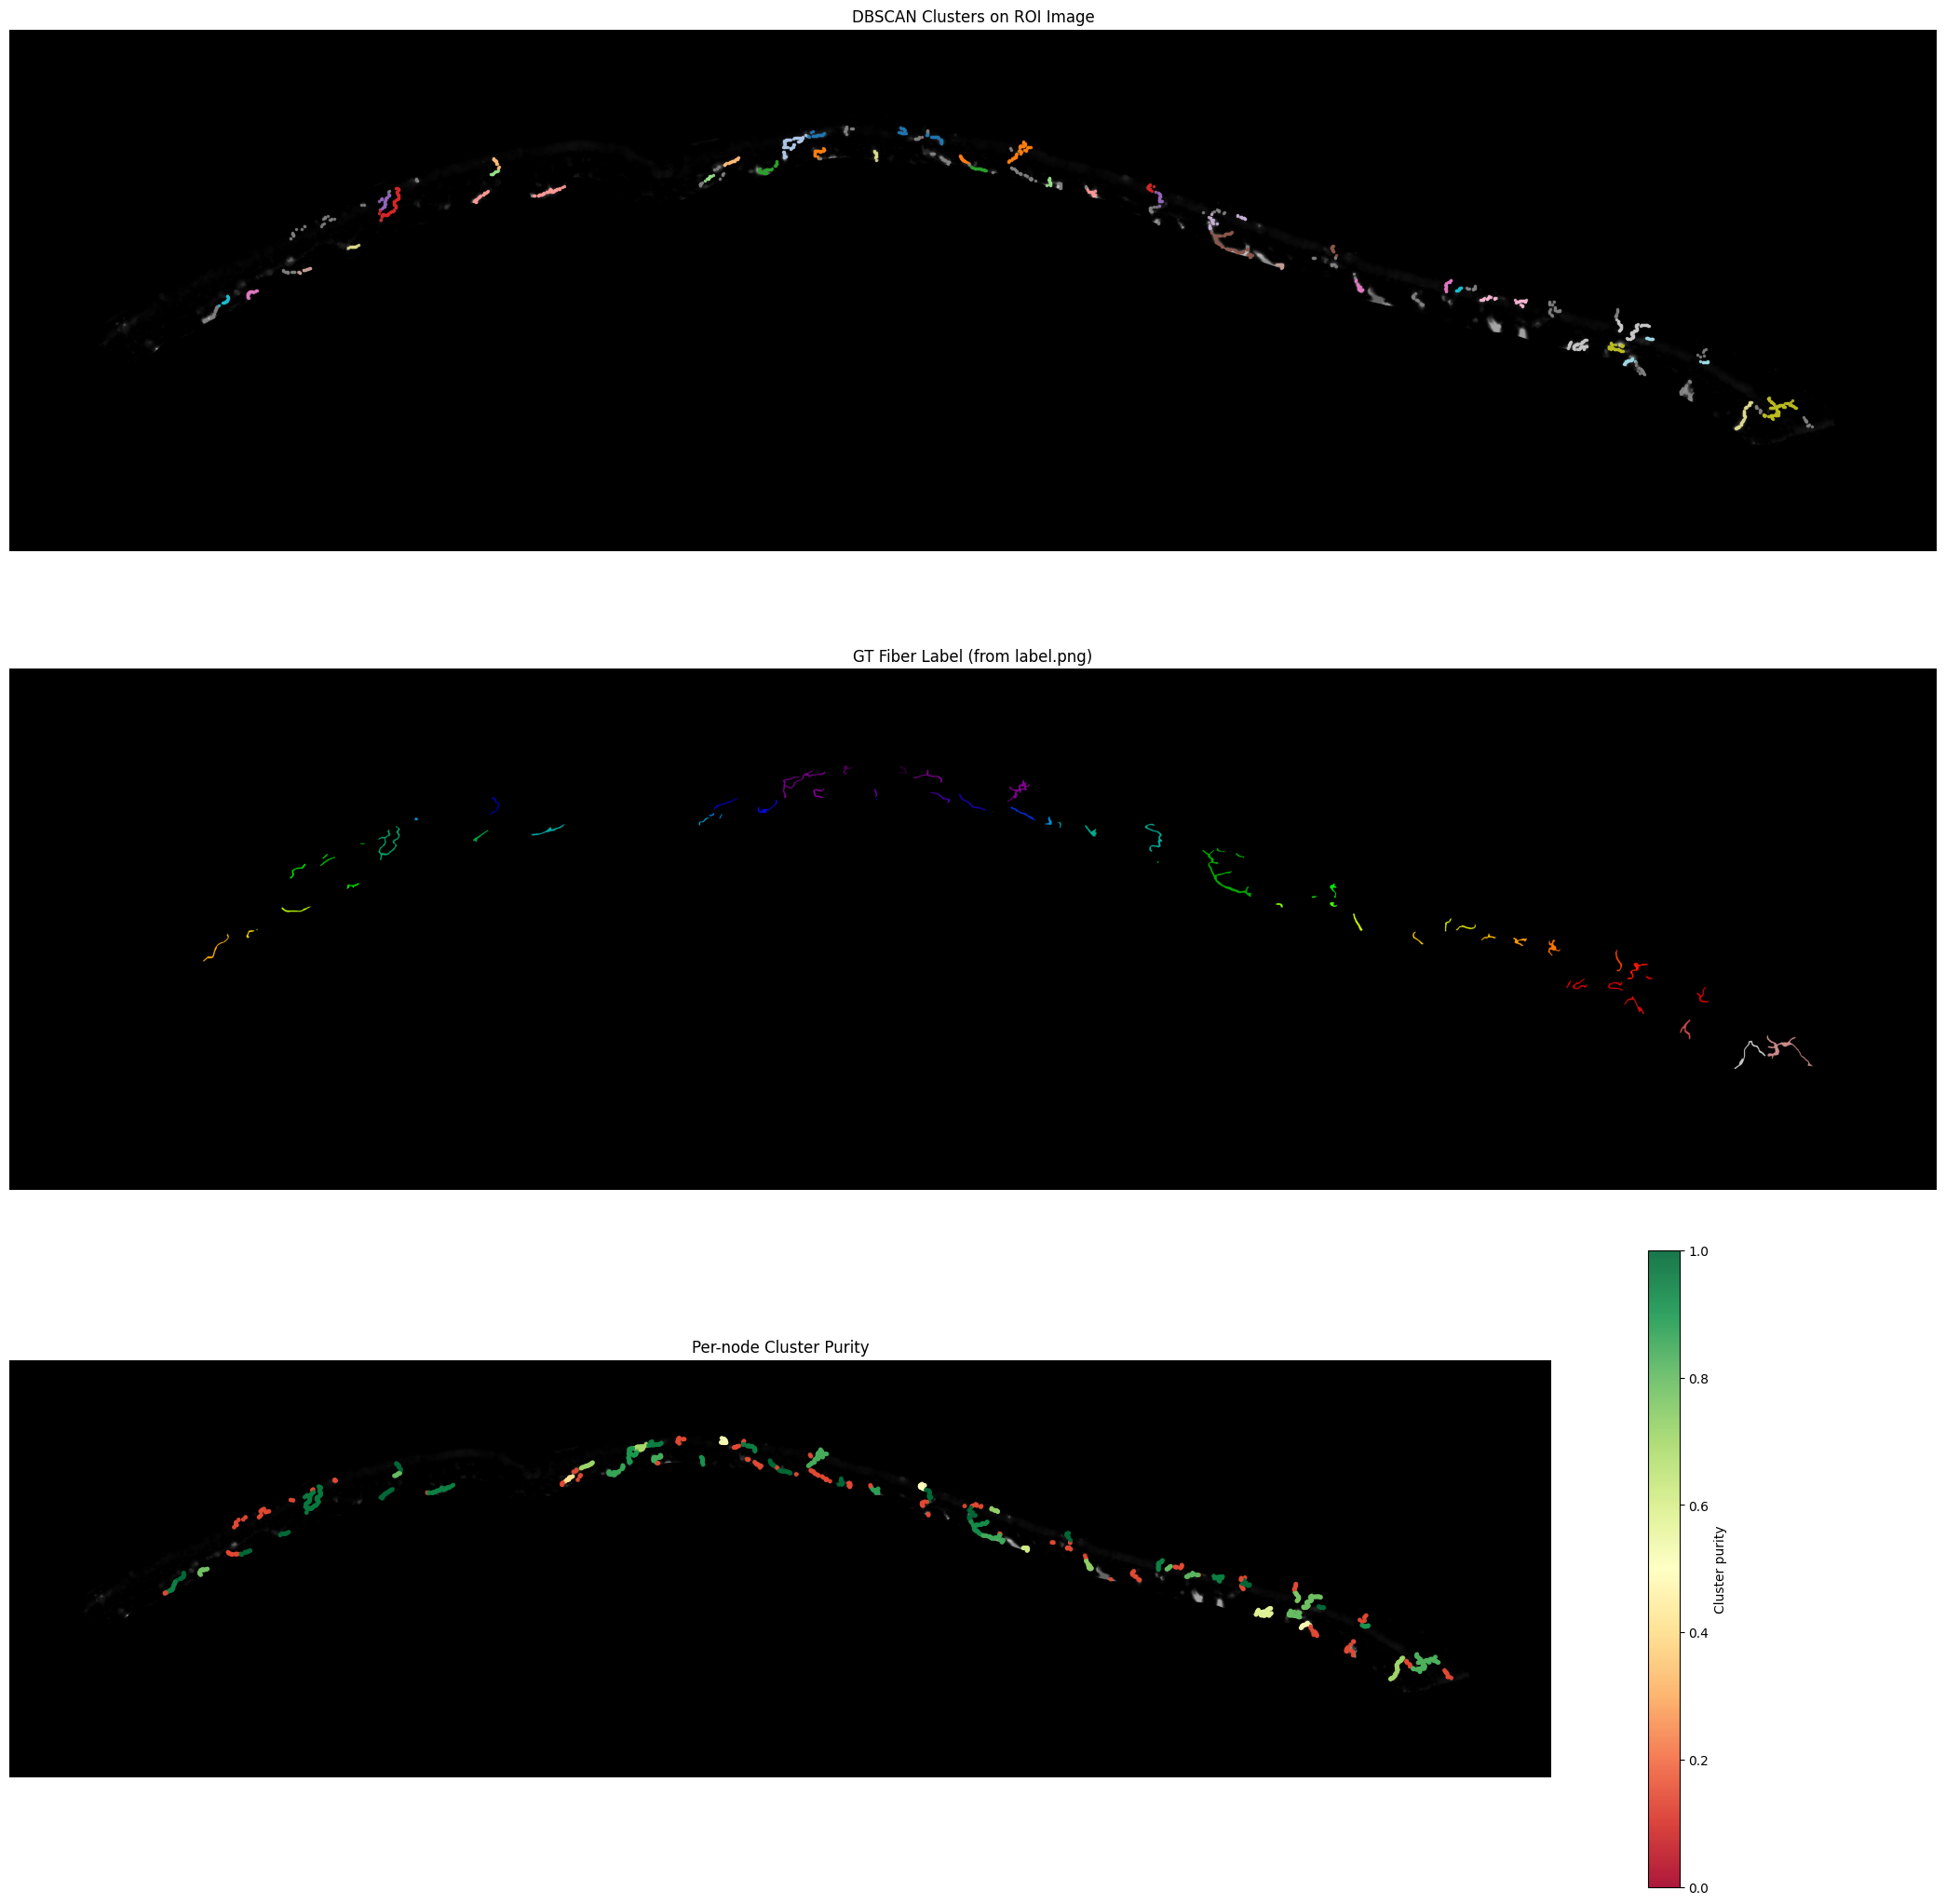

In [11]:
import matplotlib.colors as mcolors

# --- Color map: one color per cluster, grey for noise ---
unique_cids    = sorted(c for c in set(cluster_labels) if c != -1)
cmap           = plt.cm.get_cmap("tab20", max(len(unique_cids), 1))
cid_to_color   = {cid: cmap(i) for i, cid in enumerate(unique_cids)}
noise_color    = (0.5, 0.5, 0.5, 0.6)

fig, axes = plt.subplots(3, 1, figsize=(21, 21))

# ── Panel 1: DBSCAN clusters overlaid on the ROI image ──────────────────────
axes[0].imshow(roi_image, cmap="gray")
axes[0].set_title("DBSCAN Clusters on ROI Image")
for node, cid in zip(nodes, cluster_labels):
    y, x  = node
    color = cid_to_color.get(cid, noise_color)
    axes[0].plot(x, y, ".", color=color, markersize=3, alpha=0.8)
axes[0].axis("off")

# ── Panel 2: GT fiber label image ───────────────────────────────────────────
axes[1].imshow(gt_fiber_label, cmap="nipy_spectral")
axes[1].set_title("GT Fiber Label (from label.png)")
axes[1].axis("off")

# ── Panel 3: Node purity map — color = purity of the cluster this node belongs to ──
axes[2].imshow(roi_image, cmap="gray")
axes[2].set_title("Per-node Cluster Purity")
purities = np.array([
    cluster_stats[cid]["purity"] if cid in cluster_stats else 0.0
    for cid in cluster_labels
])
scatter = axes[2].scatter(
    node_positions[:, 1],   # x
    node_positions[:, 0],   # y
    c=purities,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    s=6, alpha=0.9,
)
plt.colorbar(scatter, ax=axes[2], label="Cluster purity")
axes[2].axis("off")

plt.tight_layout()
plt.show()